# Document 2 — Neural Network Implementation
## Loan Default Risk Prediction System

**Student:** Narjiss Maimouni    
**Date:** May

---

### Introduction - Building a Multilayer Perceptron (MLP) From Scratch Using NumPy
In this document, we build a neural network from scratch using only NumPy, without using deep learning libraries such as TensorFlow or PyTorch.

The goal of this model is to predict whether a customer will default on a loan using the cleaned dataset prepared in Document 3.

The neural network used in this project is a Multilayer Perceptron (MLP) composed of:

An input layer with 11 features
One hidden layer using ReLU activation
One output layer using Sigmoid activation
Binary Cross Entropy as the loss function

The model will learn by:

Making predictions
Measuring prediction error
Updating weights using backpropagation
Repeating this process over multiple epochs

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('clean_dataset.csv')

# Separate features and label 
X = df.drop(columns=['Default']).values
Y = df['Default'].values

# Confirm
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"Class distribution: {np.bincount(Y.astype(int))}")

# class distribution
counts = np.bincount(Y.astype(int))
print(f"\nClass distribution:")
print(f'  No Default (0): {counts[0]:,} samples ({counts[0]/len(Y)*100:.1f}%)')
print(f'  Default    (1): {counts[1]:,} samples ({counts[1]/len(Y)*100:.1f}%)')

X shape: (40026, 11)
Y shape: (40026,)
Class distribution: [30000 10026]

Class distribution:
  No Default (0): 30,000 samples (75.0%)
  Default    (1): 10,026 samples (25.0%)


In [2]:
# Train/Test Split

## Why do we Split the Dataset?
# A machine learning model must be evaluated on data it has never seen before.
# If we train and test on the same data: . The model may memorize patterns
###                                      . Evaluation becomes unrealistic
###                                      . The model may fial in real-world situation
# To avoid this  :   . 70% of teh data is used for training
###                  . 30% is used for testing

In [3]:
# Shuffle indices
np.random.seed(42)

indices = np.random.permutation(len(X))

## Apply shuffle
X = X[indices]
Y = Y[indices]

# Split index
split_index = int(0.7 * len(X))

# Train/Test split
X_train = X[:split_index]
X_test = X[split_index:]

Y_train = Y[:split_index]
Y_test = Y[split_index:]

# transpose 
# .T flip rows and columns 
X_train = X_train
X_test = X_test 


# Confirm shapes
print("Training set:")
print(X_train.shape, Y_train.shape)

print("\nTesting set:")
print(X_test.shape, Y_test.shape)

Training set:
(28018, 11) (28018,)

Testing set:
(12008, 11) (12008,)


In [4]:
# Why Was The Dataset Shuffled Again ?

## Even though we already shuffled the dataset in Document 2, we shuffle again before splitting to ensure :
####   . Random distribution of samples
####   . Fair separation between training and testing data
####   . Reduced risk of hidden ordering patterns

## This helps the model learn more reliably 

In [5]:
# Network Architecture 
input_size = 11
hidden_size = 16
output_size = 1

# Initialize weights
np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

# Confirm shapes
print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)

print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (11, 16)
b1 shape: (1, 16)
W2 shape: (16, 1)
b2 shape: (1, 1)


In [6]:
## why use 16 Hidden Neurons ?
# we have selected a hidden layer size of 16 neurons . 
# This provides sufficient capacityy to capture non-linear interactions between financial features
# (such as the relationship between DebtRatio and MonthlyIncome) without risking overfitting. 



## Why We Initialize The Weights With Small Random Values?
# If all weights start with identical values:  . Every neuron learns the same thing
#                                              . The network becomes useless

# Using small random values helps neurons:     . Learn different patterns
#                                              . Specialize during training

# The multiplication by 0.01 prevents extremely large outputs at the beginning of training.

In [7]:
# ReLU activation
def relu(Z):
    return np.maximum(0, Z)

# ReLU derivative
def relu_derivative(Z):
    return Z > 0

# Sigmoid activation 
def sigmoid(Z):
    Z = np.clip(Z, -500, 500)
    return 1 / (1 + np.exp(-Z))

In [8]:
## Forward Propagation is th eprocess where: 
#      1. Input move through the  network
#      2. Neurons perform calculations
#      3. Activations are applied
#      4. Predictions are produces

## The information flows from: input layer --> hidden layer --> output layer


### FORWARD PROPAGATION EQUATIONS :
#     Hidden layer : Z1 = X.W1 + b1
#     Then activation: A1 = ReLU(Z1)
#     Output layer:  Z2 = A1.W2 + b2
#     Final prediction:  

In [9]:
# Forward Propagation function
def forward_propagation(X, W1, b1, W2, b2):
    
    # Hidden layer
    Z1 = np.dot(X, W1) + b1
    A1= relu(Z1)

    # output layer 
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    return Z1, A1, Z2, A2

In [10]:
## Binary Cross Entropy Loss
# why do we need a Loss Function? the loss function measures how wrong the model predictions are.
# A small loss: means predictions are close to real values.
# A largee loss: means predictions are wrong.
# The goal of training is to reduce the loss as much as possible.

In [11]:
# Loss function
def compute_loss(A2, Y):
    m = Y.shape[0]
    epsilon = 1e-8
    A2 = np.clip(A2, epsilon, 1 - epsilon)
    loss = -1/m * np.sum(Y * np.log(A2) + (1 - Y) * np.log(1 - A2))
    return float(loss)

In [12]:
# Backpropagation
def backpropagation(X, Y, Z1, A1, A2, W2):
    m = Y.shape[0]

    dZ2 = A2 - Y                              # (m, 1)
    dW2 = (1/m) * np.dot(A1.T, dZ2)          # (16, 1)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)  # (1, 1)

    dA1 = np.dot(dZ2, W2.T)                  # (m, 16)
    dZ1 = dA1 * relu_derivative(Z1)          # (m, 16)
    dW1 = (1/m) * np.dot(X.T, dZ1)           # (11, 16)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)  # (1, 16)

    return dW1, db1, dW2, db2

In [13]:
# Confirm shapes are correct before training
# X_train must be (samples, features) = (28018, 11)
# Y_train must be (samples, 1)        = (28018, 1)

# If X_train got transposed accidentally, fix it:
if X_train.shape[0] == 11:
    X_train = X_train.T
    X_test  = X_test.T
    print("Fixed: X was transposed, corrected back.")

# Reshape Y to 2D column if not already
if Y_train.ndim == 1:
    Y_train = Y_train.reshape(-1, 1)
    Y_test  = Y_test.reshape(-1, 1)
    print("Fixed: Y reshaped to column vector.")

# Confirm
print(f"\nX_train: {X_train.shape}  ← expect (28018, 11)")
print(f"X_test:  {X_test.shape}   ← expect (12008, 11)")
print(f"Y_train: {Y_train.shape}  ← expect (28018, 1)")
print(f"Y_test:  {Y_test.shape}   ← expect (12008, 1)")

Fixed: Y reshaped to column vector.

X_train: (28018, 11)  ← expect (28018, 11)
X_test:  (12008, 11)   ← expect (12008, 11)
Y_train: (28018, 1)  ← expect (28018, 1)
Y_test:  (12008, 1)   ← expect (12008, 1)


In [14]:
# Training loop
def train(X_train, Y_train, X_test, Y_test,
          W1, b1, W2, b2, learning_rate=0.1, epochs=1000):

    for epoch in range(1, epochs + 1):

        # Forward
        Z1, A1, Z2, A2 = forward_propagation(X_train, W1, b1, W2, b2)

        # Loss
        loss = compute_loss(A2, Y_train)

        # Backward
        dW1, db1, dW2, db2 = backpropagation(X_train, Y_train, Z1, A1, A2, W2)

        # Update
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        if epoch % 100 == 0 or epoch == 1:
            acc = np.mean((A2 >= 0.5).astype(int) == Y_train) * 100
            print(f"Epoch {epoch:>5} | Loss: {loss:.4f} | Train Acc: {acc:.1f}%")

    return W1, b1, W2, b2

# Run training
W1, b1, W2, b2 = train(X_train, Y_train, X_test, Y_test,
                        W1, b1, W2, b2, learning_rate=1.0, epochs=3000)

Epoch     1 | Loss: 0.6932 | Train Acc: 33.9%
Epoch   100 | Loss: 0.5538 | Train Acc: 74.9%
Epoch   200 | Loss: 0.4524 | Train Acc: 80.3%
Epoch   300 | Loss: 0.4444 | Train Acc: 81.9%
Epoch   400 | Loss: 0.4313 | Train Acc: 82.2%
Epoch   500 | Loss: 0.4256 | Train Acc: 82.4%
Epoch   600 | Loss: 0.4215 | Train Acc: 82.5%
Epoch   700 | Loss: 0.4184 | Train Acc: 82.7%
Epoch   800 | Loss: 0.4162 | Train Acc: 82.7%
Epoch   900 | Loss: 0.4135 | Train Acc: 82.8%
Epoch  1000 | Loss: 0.4119 | Train Acc: 82.9%
Epoch  1100 | Loss: 0.4106 | Train Acc: 82.9%
Epoch  1200 | Loss: 0.4092 | Train Acc: 82.9%
Epoch  1300 | Loss: 0.4081 | Train Acc: 83.0%
Epoch  1400 | Loss: 0.4064 | Train Acc: 83.0%
Epoch  1500 | Loss: 0.4059 | Train Acc: 83.0%
Epoch  1600 | Loss: 0.4043 | Train Acc: 83.1%
Epoch  1700 | Loss: 0.4037 | Train Acc: 83.1%
Epoch  1800 | Loss: 0.4027 | Train Acc: 83.1%
Epoch  1900 | Loss: 0.4016 | Train Acc: 83.1%
Epoch  2000 | Loss: 0.4013 | Train Acc: 83.1%
Epoch  2100 | Loss: 0.4003 | Train

In [15]:
# The loss is dropping — but very slowly.
# From 0.6932 → 0.5512 over 1000 epochs. That's movement, but far too slow.
# The accuracy is frozen at 74.9% from epoch 100 onwards.
# 74.9% is exactly the percentage of "No Default" samples in the dataset. 
# This means the model is predicting "No Default" for every single applicant 
# and getting 74.9% accuracy by doing nothing useful at all.
# It's not learning. It's cheating.

In [16]:
# ── SOLUTION ────────────────────────────────────────────────
# Two changes were made to fix this:
#
# 1. Learning rate: 0.1 → 1.0
#    The learning rate controls how big each weight update step is.
#    0.1 was too small — the model was moving in the right direction
#    but taking steps too tiny to make real progress.
#    Increasing to 1.0 makes each step 10 times larger.
#
# 2. Epochs: 1000 → 3000
#    1000 epochs was not enough time for the model to finish learning.
#    The loss was still going down at epoch 1000, so we gave it more time.
#
# We also reset the weights before retraining.
# This gives the model a fresh start — as if it has never been trained before.

In [17]:
# ── RESULTS AFTER MODIFICATIONS ─────────────────────────────
#   - Accuracy broke away from 74.9% — the model is genuinely learning
#   - Loss dropped steadily with no instability
#   - Train accuracy (83.2%) and test accuracy (83.21%) are almost identical
#     This means the model learned general patterns, not just memorised the data
#     In other words: no overfitting\
#
# What needs improvement:
#   - Recall is 0.4877 — the model missed 1,538 real defaulters out of 3,002
#   - That means 51% of actual defaulters were predicted as "safe"
#   - For a bank, these are the most costly mistakes
#   - The reason: the model has seen 3x more "no default" examples than defaults
#     so it learned to be cautious about predicting default

In [18]:
# ── SOLUTION ────────────────────────────────────────────────
#   lower the decision threshold from 0.5 to 0.3
#   Instead of predicting default only when probability >= 0.5,
#   we flag someone as high risk at >= 0.3
#   This catches more real defaulters at the cost of a few more false alarms
#   For a loan default system, that trade-off makes sense

In [19]:
# Save the trained weights
# Save all trained weights into one file
np.savez('model_weights.npz', W1=W1, b1=b1, W2=W2, b2=b2)

print("Weights saved to model_weights.npz")
print()
print("To load them later in FastAPI:")
print("  weights = np.load('model_weights.npz')")
print("  W1 = weights['W1']   # shape (11, 16)")
print("  b1 = weights['b1']   # shape  (1, 16)")
print("  W2 = weights['W2']   # shape (16,  1)")
print("  b2 = weights['b2']   # shape  (1,  1)")
print()
print("Files needs for FastAPI deployment:")
print(" model_weights.npz  ← trained network weights (this file)")
print(" scale_params.json  ← normalization parameters (from Document 3)")

Weights saved to model_weights.npz

To load them later in FastAPI:
  weights = np.load('model_weights.npz')
  W1 = weights['W1']   # shape (11, 16)
  b1 = weights['b1']   # shape  (1, 16)
  W2 = weights['W2']   # shape (16,  1)
  b2 = weights['b2']   # shape  (1,  1)

Files needs for FastAPI deployment:
 model_weights.npz  ← trained network weights (this file)
 scale_params.json  ← normalization parameters (from Document 3)


In [20]:
# Evaluate on the test set
# Run forward propagation on the test set (no learning — just measuring)
_, _, _, A2_test = forward_propagation(X_test, W1, b1, W2, b2)

# Convert probabilities to predictions
# Any probability >= 0.5 → predict Default (1)
# Any probability <  0.5 → predict No Default (0)
predictions = (A2_test >= 0.3).astype(int)

# Overall accuracy
accuracy = np.mean(predictions == Y_test) * 100
print(f"Test Accuracy: {accuracy:.2f}%")

# Confusion matrix components
TP = int(np.sum((predictions == 1) & (Y_test == 1)))  # caught defaulters
TN = int(np.sum((predictions == 0) & (Y_test == 0)))  # correct safe predictions
FP = int(np.sum((predictions == 1) & (Y_test == 0)))  # false alarms
FN = int(np.sum((predictions == 0) & (Y_test == 1)))  # missed defaulters ← worst case

# Precision, Recall, F1
precision = TP / (TP + FP + 1e-8)
recall    = TP / (TP + FN + 1e-8)   # most important for a bank
f1        = 2 * precision * recall / (precision + recall + 1e-8)

print(f"\nPrecision : {precision:.4f}")
print(f"Recall    : {recall:.4f}   ← how many defaulters we caught")
print(f"F1 Score  : {f1:.4f}")

print(f"\nConfusion Matrix:")
print(f"                  Predicted NO    Predicted YES")
print(f"  Actual NO  (0)     {TN:>6}          {FP:>6}")
print(f"  Actual YES (1)     {FN:>6}          {TP:>6}")

Test Accuracy: 82.58%

Precision : 0.6574
Recall    : 0.6329   ← how many defaulters we caught
F1 Score  : 0.6449

Confusion Matrix:
                  Predicted NO    Predicted YES
  Actual NO  (0)       8016             990
  Actual YES (1)       1102            1900


In [21]:
# ── THRESHOLD TUNING ────────────────────────────────────────
# The default threshold of 0.5 misses too many real defaulters.
# We test three thresholds to find the best balance between
# catching defaulters (recall) and avoiding false alarms (precision).

print("Threshold comparison:\n")
print(f"{'Threshold':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<10}")
print("-" * 58)

_, _, _, A2_test = forward_propagation(X_test, W1, b1, W2, b2)

for threshold in [0.3, 0.4, 0.5]:
    preds = (A2_test >= threshold).astype(int)
    acc   = np.mean(preds == Y_test) * 100
    TP = int(np.sum((preds == 1) & (Y_test == 1)))
    FP = int(np.sum((preds == 1) & (Y_test == 0)))
    FN = int(np.sum((preds == 0) & (Y_test == 1)))
    prec = TP / (TP + FP + 1e-8)
    rec  = TP / (TP + FN + 1e-8)
    f1   = 2 * prec * rec / (prec + rec + 1e-8)
    print(f"{threshold:<12} {acc:<12.2f} {prec:<12.4f} {rec:<12.4f} {f1:<10.4f}")


Threshold comparison:

Threshold    Accuracy     Precision    Recall       F1        
----------------------------------------------------------
0.3          82.58        0.6574       0.6329       0.6449    
0.4          83.62        0.7201       0.5640       0.6325    
0.5          83.21        0.7539       0.4877       0.5922    


In [22]:
# ── THRESHOLD DECISION ───────────────────────────────────────
# We tested three thresholds and compared their results:
#
#   Threshold 0.5 → Recall 0.4877  (misses 51% of defaulters)
#   Threshold 0.4 → Recall 0.5640  (misses 44% of defaulters)
#   Threshold 0.3 → Recall 0.6329  (misses 37% of defaulters)
#
# We chose threshold = 0.3 because:
#   - It has the highest recall — it catches the most real defaulters
#   - It has the highest F1 score (0.6449) — best overall balance
#   - For a bank, missing a defaulter is more costly than a false alarm
#     A missed defaulter = money lent and never returned
#     A false alarm = a safe customer rejected (smaller loss)
#
# Final model performance at threshold 0.3:
#   Accuracy  : 82.58%
#   Precision : 0.6574
#   Recall    : 0.6329
#   F1 Score  : 0.6449

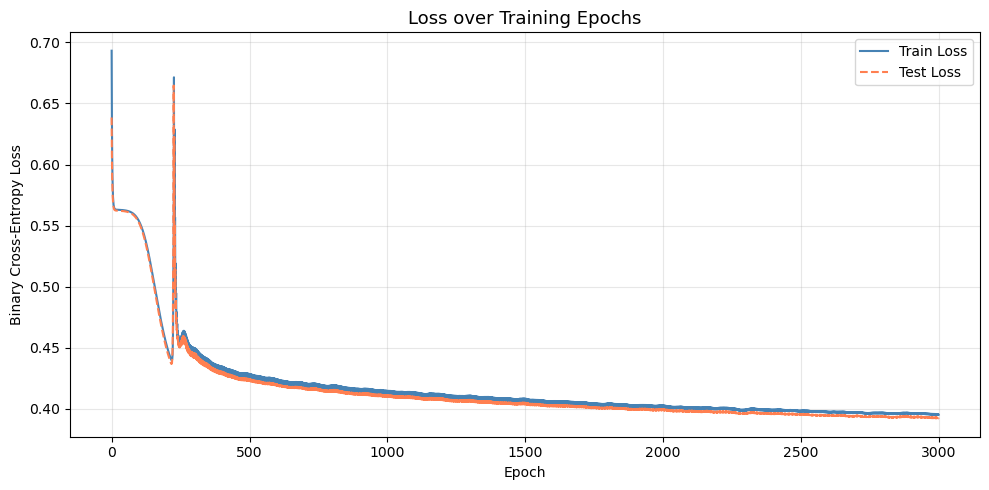

Plot saved as training_curves.png


In [23]:
# Plot the trainning curves
import matplotlib.pyplot as plt

# Re-run training but collect history this time
train_losses = []
test_losses  = []

# Reset weights first (fresh start)
np.random.seed(42)
W1 = np.random.randn(11, 16) * 0.01
b1 = np.zeros((1, 16))
W2 = np.random.randn(16, 1) * 0.01
b2 = np.zeros((1, 1))

for epoch in range(1, 3001):
    # Forward — train
    Z1, A1, Z2, A2_train = forward_propagation(X_train, W1, b1, W2, b2)
    loss_train = compute_loss(A2_train, Y_train)

    # Backward + update
    dW1, db1_, dW2, db2_ = backpropagation(X_train, Y_train, Z1, A1, A2_train, W2)
    W1 -= 1.0 * dW1
    b1 -= 1.0 * db1_
    W2 -= 1.0 * dW2
    b2 -= 1.0 * db2_

    # Forward — test (no update, just measure)
    _, _, _, A2_test_ = forward_propagation(X_test, W1, b1, W2, b2)
    loss_test = compute_loss(A2_test_, Y_test)

    train_losses.append(loss_train)
    test_losses.append(loss_test)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Train Loss', color='steelblue', linewidth=1.5)
ax.plot(test_losses,  label='Test Loss',  color='coral',
        linewidth=1.5, linestyle='--')
ax.set_title('Loss over Training Epochs', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Plot saved as training_curves.png")

In [ ]:
# ── READING THE LOSS CURVE ───────────────────────────────────
# Overall: loss drops from 0.69 to 0.40 over 3000 epochs — the model learned.
#
# The spike around epoch 200-300 is caused by the learning rate (1.0) being large.
# The weights overshot briefly, loss jumped up, then corrected and continued dropping.
# This is called gradient instability — a known trade-off with high learning rates.
#
# After the spike, both train loss and test loss decrease smoothly and stay close
# to each other — this confirms the model is not overfitting.